# Ejemplo de convolución

El siguiente códico aplica sobre una imagen del Dataset el filtro de detección de bordes Laplaciano, y tras la convolución, aplica un Max-Pooling que reduce cada lado ocho veces.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


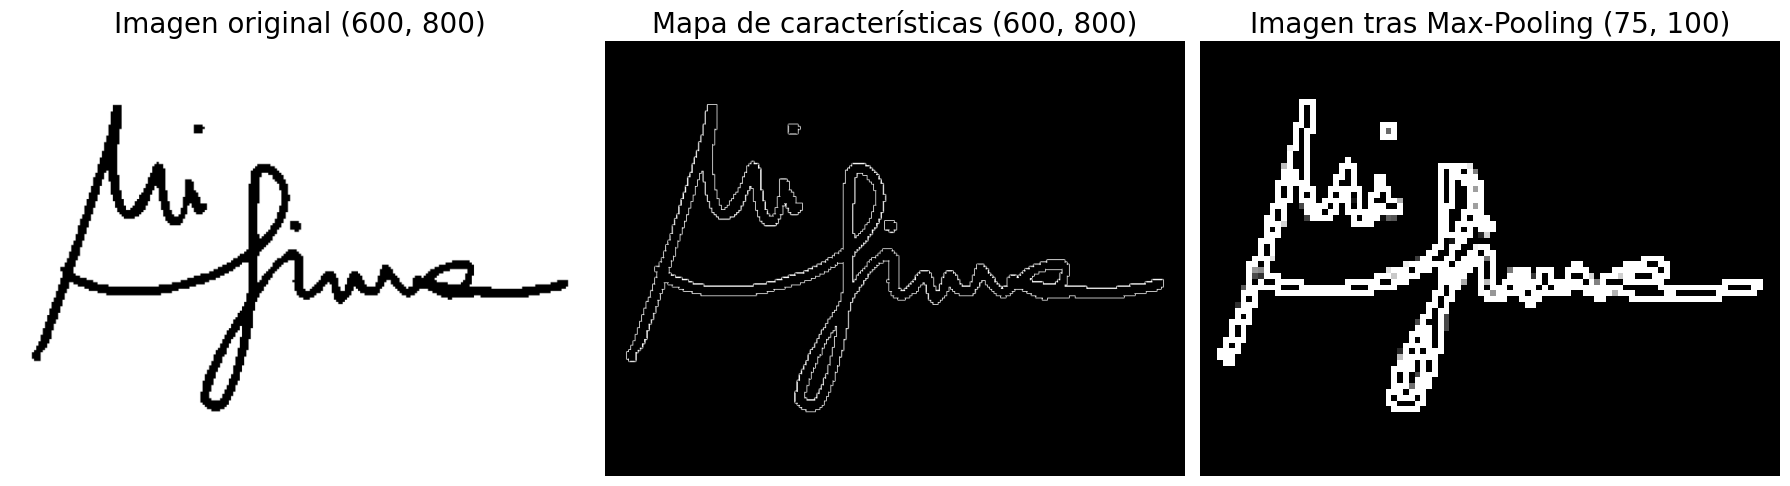

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/DATASET/IMAGENES_LOW/001_00_01_02.png'
img_original = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)


# Filtro de Detección de Bordes Laplaciano
filtro_bordes = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])

# Convolucion
img_convolucion = cv2.filter2D(img_original, -1, filtro_bordes)

# Max-Pooling
factor = 8
H, W = img_convolucion.shape
H_ajustado = (H // factor) * factor
W_ajustado = (W // factor) * factor
img_recortada = img_convolucion[:H_ajustado, :W_ajustado]

img_pooling = img_recortada.reshape(H_ajustado // factor, factor, W_ajustado // factor, factor).max(axis=(1, 3))


# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title(f'Imagen original {img_original.shape}', fontsize=20)
axes[0].axis('off')

# Convolución
axes[1].imshow(img_convolucion, cmap='gray')
axes[1].set_title(f'Mapa de características {img_convolucion.shape}', fontsize=20)
axes[1].axis('off')

# Pooling
axes[2].imshow(img_pooling, cmap='gray')
axes[2].set_title(f'Imagen tras Max-Pooling {img_pooling.shape}', fontsize=20)
axes[2].axis('off')

plt.tight_layout()
plt.show()